In [1]:
import json
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# -------------------------
# Box helpers (same as training)
# -------------------------
def cxcywh_to_xyxy(cxcywh: torch.Tensor) -> torch.Tensor:
    cx, cy, w, h = cxcywh.unbind(-1)
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    return torch.stack([x1, y1, x2, y2], dim=-1)

def clamp01(x: torch.Tensor) -> torch.Tensor:
    return x.clamp(0.0, 1.0)

def load_label_map(label_map_json: str | Path):
    label_map_json = Path(label_map_json)
    data = json.loads(label_map_json.read_text())
    # keys in json might be strings for idx_to_label
    idx_to_label = {int(k): v for k, v in data["idx_to_label"].items()}
    label_to_idx = data["label_to_idx"]
    return label_to_idx, idx_to_label

def draw_predictions(
    pil_img: Image.Image,
    boxes_xyxy_norm: torch.Tensor,
    labels: list[str],
    scores: torch.Tensor,
    title: str = "",
    score_fmt: str = "{:.2f}",
    max_draw: int = 20
):
    """
    Draw normalized xyxy boxes on the original PIL image.
    """
    w, h = pil_img.size
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(pil_img)
    ax.axis("off")
    if title:
        ax.set_title(title)

    n = min(len(labels), boxes_xyxy_norm.shape[0], scores.numel(), max_draw)

    for i in range(n):
        x1, y1, x2, y2 = boxes_xyxy_norm[i].tolist()
        x1 *= w; x2 *= w; y1 *= h; y2 *= h
        rect = patches.Rectangle((x1, y1), (x2 - x1), (y2 - y1),
                                 linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(
            x1, max(0, y1 - 5),
            f"{labels[i]} {score_fmt.format(float(scores[i]))}",
            color="red",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2),
        )
    plt.show()

In [2]:
# -------------------------
# 2D sine positional encoding (DETR-style)
# -------------------------
class PositionEmbeddingSine(nn.Module):
    def __init__(self, num_pos_feats=128, temperature=10000):
        super().__init__()
        self.num_pos_feats = num_pos_feats
        self.temperature = temperature

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B,C,H,W]
        B, _, H, W = x.shape
        device = x.device

        y_embed = torch.linspace(0, 1, H, device=device).unsqueeze(1).repeat(1, W)
        x_embed = torch.linspace(0, 1, W, device=device).unsqueeze(0).repeat(H, 1)

        dim_t = torch.arange(self.num_pos_feats, device=device, dtype=torch.float32)
        dim_t = self.temperature ** (2 * (dim_t // 2) / self.num_pos_feats)

        pos_x = x_embed[..., None] / dim_t
        pos_y = y_embed[..., None] / dim_t

        pos_x = torch.stack((pos_x[..., 0::2].sin(), pos_x[..., 1::2].cos()), dim=3).flatten(2)
        pos_y = torch.stack((pos_y[..., 0::2].sin(), pos_y[..., 1::2].cos()), dim=3).flatten(2)

        pos = torch.cat((pos_y, pos_x), dim=2)  # [H,W,2*num_pos_feats]
        pos = pos.permute(2, 0, 1).unsqueeze(0).repeat(B, 1, 1, 1)  # [B,2F,H,W]
        return pos


# -------------------------
# CORnet feature extractor (hook a spatial layer)
# -------------------------
class CornetSpatialBackbone(nn.Module):
    def __init__(self, cornet_model: nn.Module, feature_layer: str = "IT"):
        super().__init__()
        self.model = cornet_model
        self.feature_layer = feature_layer
        self._feat = None

        if not hasattr(self.model, feature_layer):
            raise ValueError(f"CORnet model has no attribute '{feature_layer}'. Try one of: V1,V2,V4,IT")
        layer_mod = getattr(self.model, feature_layer)

        def hook_fn(module, inp, out):
            self._feat = out

        layer_mod.register_forward_hook(hook_fn)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _ = self.model(x)
        if self._feat is None:
            raise RuntimeError("Feature hook did not capture output. Check feature_layer.")
        return self._feat


# -------------------------
# DETR-lite head
# -------------------------
class CornetDETR(nn.Module):
    def __init__(
        self,
        cornet_base: nn.Module,
        num_classes: int,
        num_queries: int = 10,
        feature_layer: str = "IT",
        d_model: int = 256,
        nhead: int = 8,
        num_decoder_layers: int = 4,
        dim_feedforward: int = 1024,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.num_queries = num_queries
        self.no_object_class = num_classes  # index C (so total C+1)

        self.backbone = CornetSpatialBackbone(cornet_base, feature_layer=feature_layer)

        # lazy projection (created on first forward)
        self.proj = None
        self.d_model = d_model

        self.pos_embed = PositionEmbeddingSine(num_pos_feats=d_model // 2)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward, dropout=dropout,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)

        self.query_embed = nn.Embedding(num_queries, d_model)

        self.class_head = nn.Linear(d_model, num_classes + 1)
        self.box_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 4),
        )

    def _ensure_proj(self, feat: torch.Tensor):
        if self.proj is None:
            in_ch = feat.shape[1]
            self.proj = nn.Conv2d(in_ch, self.d_model, kernel_size=1).to(feat.device)
            self.add_module("input_proj", self.proj)

    def forward(self, x: torch.Tensor):
        feat = self.backbone(x)              # [B,C,H,W]
        self._ensure_proj(feat)

        src = self.proj(feat)               # [B,d,H,W]
        pos = self.pos_embed(src)           # [B,d,H,W]

        B, d, H, W = src.shape
        src_tokens = src.flatten(2).permute(0, 2, 1)  # [B,HW,d]
        pos_tokens = pos.flatten(2).permute(0, 2, 1)  # [B,HW,d]

        q = self.query_embed.weight.unsqueeze(0).repeat(B, 1, 1)  # [B,Q,d]
        hs = self.decoder(tgt=q, memory=src_tokens + pos_tokens)  # [B,Q,d]

        logits = self.class_head(hs)                              # [B,Q,C+1]
        boxes = torch.sigmoid(self.box_head(hs))                  # [B,Q,4] cxcywh
        return {"pred_logits": logits, "pred_boxes": boxes}

In [4]:
# ---- paths (EDIT THESE) ----
CKPT_PATH = Path("/zpool/vladlab/data_drive/geogaze_data/cornet_coco_bboxes/cornetz/identification_critical/best.pth.tar")
LABEL_MAP_JSON = CKPT_PATH.parent / "label_map.json"

CORN_NET_REPO = Path("/zpool/vladlab/active_drive/omaltz/git_repos/CORnet")  # same as training

# ---- device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ---- import cornet from your repo ----
import sys
sys.path.insert(0, str(CORN_NET_REPO))
import cornet
print("Imported cornet from:", cornet.__file__)

# ---- load checkpoint ----
ckpt = torch.load(CKPT_PATH, map_location=device)
args = ckpt.get("args", {})
print("Checkpoint epoch:", ckpt.get("epoch"), "best_val:", ckpt.get("best_val"))

# ---- load label map ----
label_to_idx, idx_to_label = load_label_map(LABEL_MAP_JSON)
num_classes = int(args.get("num_classes", len(label_to_idx)))
print("num_classes:", num_classes, "| label_map classes:", len(label_to_idx))

# ---- rebuild CORnet base exactly as training ----
model_letter = str(args.get("model", "Z")).lower()
feature_layer = str(args.get("feature_layer", "V4"))
times = int(args.get("times", 5))

base_ctor = getattr(cornet, f"cornet_{model_letter}")
if model_letter == "r":
    cornet_base = base_ctor(pretrained=False, map_location=device, times=times)
else:
    cornet_base = base_ctor(pretrained=False, map_location=device)

if hasattr(cornet_base, "module"):
    cornet_base = cornet_base.module

# ---- rebuild DETR head using ckpt args (fallbacks match your script defaults) ----
model = CornetDETR(
    cornet_base=cornet_base,
    num_classes=num_classes,
    num_queries=int(args.get("num_queries", 10)),
    feature_layer=feature_layer,
    d_model=int(args.get("d_model", 256)),
    nhead=int(args.get("nhead", 8)),
    num_decoder_layers=int(args.get("num_decoder_layers", 4)),
    dim_feedforward=int(args.get("dim_feedforward", 1024)),
).to(device)

# IMPORTANT: run 1 dummy forward so lazy input_proj exists before loading (cleaner)
normalize = torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                             std=[0.229, 0.224, 0.225])
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    normalize,
])
dummy = torch.zeros(1, 3, 224, 224, device=device)
with torch.no_grad():
    _ = model(dummy)

# ---- load weights ----
missing, unexpected = model.load_state_dict(ckpt["model"], strict=False)
print("Loaded checkpoint.")
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))
if len(missing) < 30:
    print("  ", missing)
if len(unexpected) < 30:
    print("  ", unexpected)

model.eval()

device: cuda
Imported cornet from: /zpool/vladlab/active_drive/omaltz/git_repos/CORnet/cornet/__init__.py
Checkpoint epoch: 22 best_val: 2.726041846142875
num_classes: 70 | label_map classes: 70
Loaded checkpoint.
Missing keys: 0
Unexpected keys: 0
   []
   []


CornetDETR(
  (backbone): CornetSpatialBackbone(
    (model): Sequential(
      (V1): CORblock_Z(
        (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (V2): CORblock_Z(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (V4): CORblock_Z(
        (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (IT): CORblock_Z(
        (conv): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   


000000000797.jpg
  elephant                        0.552
  elephant                        0.476
  elephant                        0.454
  elephant                        0.430
  elephant                        0.427


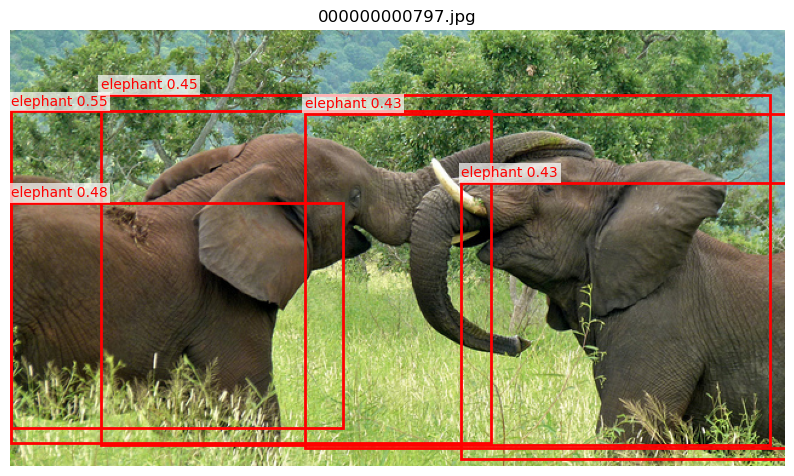

In [31]:
@torch.no_grad()
def predict_on_image(
    image_path: str | Path,
    model: nn.Module,
    idx_to_label: dict[int, str],
    score_thresh: float = 0.1,
    topk: int = 10,
):
    image_path = Path(image_path)
    pil = Image.open(image_path).convert("RGB")

    x = transform(pil).unsqueeze(0).to(device)  # [1,3,224,224]
    out = model(x)

    logits = out["pred_logits"][0]  # [Q,C+1]
    boxes_cxcywh = out["pred_boxes"][0]  # [Q,4]

    probs = logits.softmax(-1)  # [Q,C+1]
    scores, labels = probs.max(-1)  # best class per query

    no_obj = (labels == num_classes)
    keep = (~no_obj) & (scores >= score_thresh)

    kept_scores = scores[keep]
    kept_labels = labels[keep]
    kept_boxes = boxes_cxcywh[keep]

    if kept_scores.numel() == 0:
        print(f"{image_path.name}: no predictions above thresh={score_thresh}")
        draw_predictions(pil, torch.empty((0,4)), [], torch.empty((0,)), title=image_path.name)
        return

    # sort by score desc
    order = torch.argsort(kept_scores, descending=True)
    order = order[:topk]

    kept_scores = kept_scores[order].cpu()
    kept_labels = kept_labels[order].cpu()
    kept_boxes = kept_boxes[order].cpu()

    boxes_xyxy = clamp01(cxcywh_to_xyxy(kept_boxes))  # normalized xyxy

    label_names = [idx_to_label.get(int(i), f"cls_{int(i)}") for i in kept_labels.tolist()]

    print(f"\n{image_path.name}")
    for name, sc in zip(label_names, kept_scores.tolist()):
        print(f"  {name:30s}  {sc:.3f}")

    draw_predictions(
        pil_img=pil,
        boxes_xyxy_norm=boxes_xyxy,
        labels=label_names,
        scores=kept_scores,
        title=image_path.name,
        max_draw=topk
    )

# ---- try a few images ----
TEST_IMAGES = [
    # EDIT: put your test image paths here
    "/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/train_working3/000000000797.jpg",
]

for p in TEST_IMAGES:
    predict_on_image(p, model, idx_to_label, score_thresh=0.000005, topk=10)